<a href="https://colab.research.google.com/github/uwol1116/GAI-Class/blob/main/03-autograd_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 2. Preprocess the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

# 1. Load the MNIST dataset using torchvision.datasets.
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=100, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 40.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.24MB/s]


In [5]:
# 3. Implement the model y=Wx+b
model = nn.Linear(784, 10)

# 4. Use cross entropy loss
criterion = nn.CrossEntropyLoss()

In [6]:
# 5. Train the model using gradient descent.
optimizer = optim.SGD(model.parameters(), lr=0.01)

num_epochs = 10
loss_list = []

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            loss_list.append(loss.item())

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/10], Loss: 0.6631
Epoch [2/10], Loss: 0.4842
Epoch [3/10], Loss: 0.4968
Epoch [4/10], Loss: 0.5250
Epoch [5/10], Loss: 0.4768
Epoch [6/10], Loss: 0.5144
Epoch [7/10], Loss: 0.2914
Epoch [8/10], Loss: 0.5983
Epoch [9/10], Loss: 0.2965
Epoch [10/10], Loss: 0.3070



Test Accuracy: 90.36%


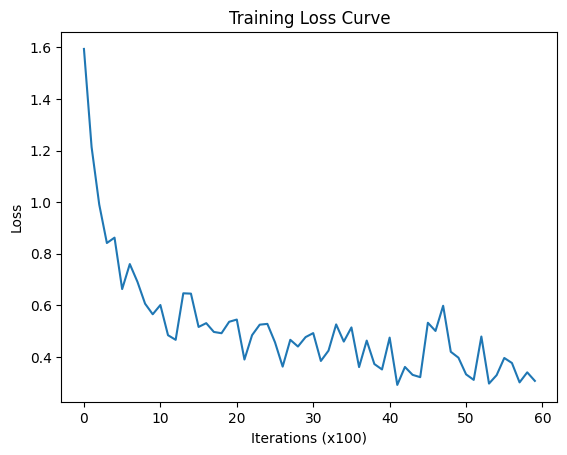

In [7]:
# 6. Report
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'\nTest Accuracy: {100 * correct / total}%')

plt.plot(loss_list)
plt.title('Training Loss Curve')
plt.xlabel('Iterations (x100)')
plt.ylabel('Loss')
plt.show()